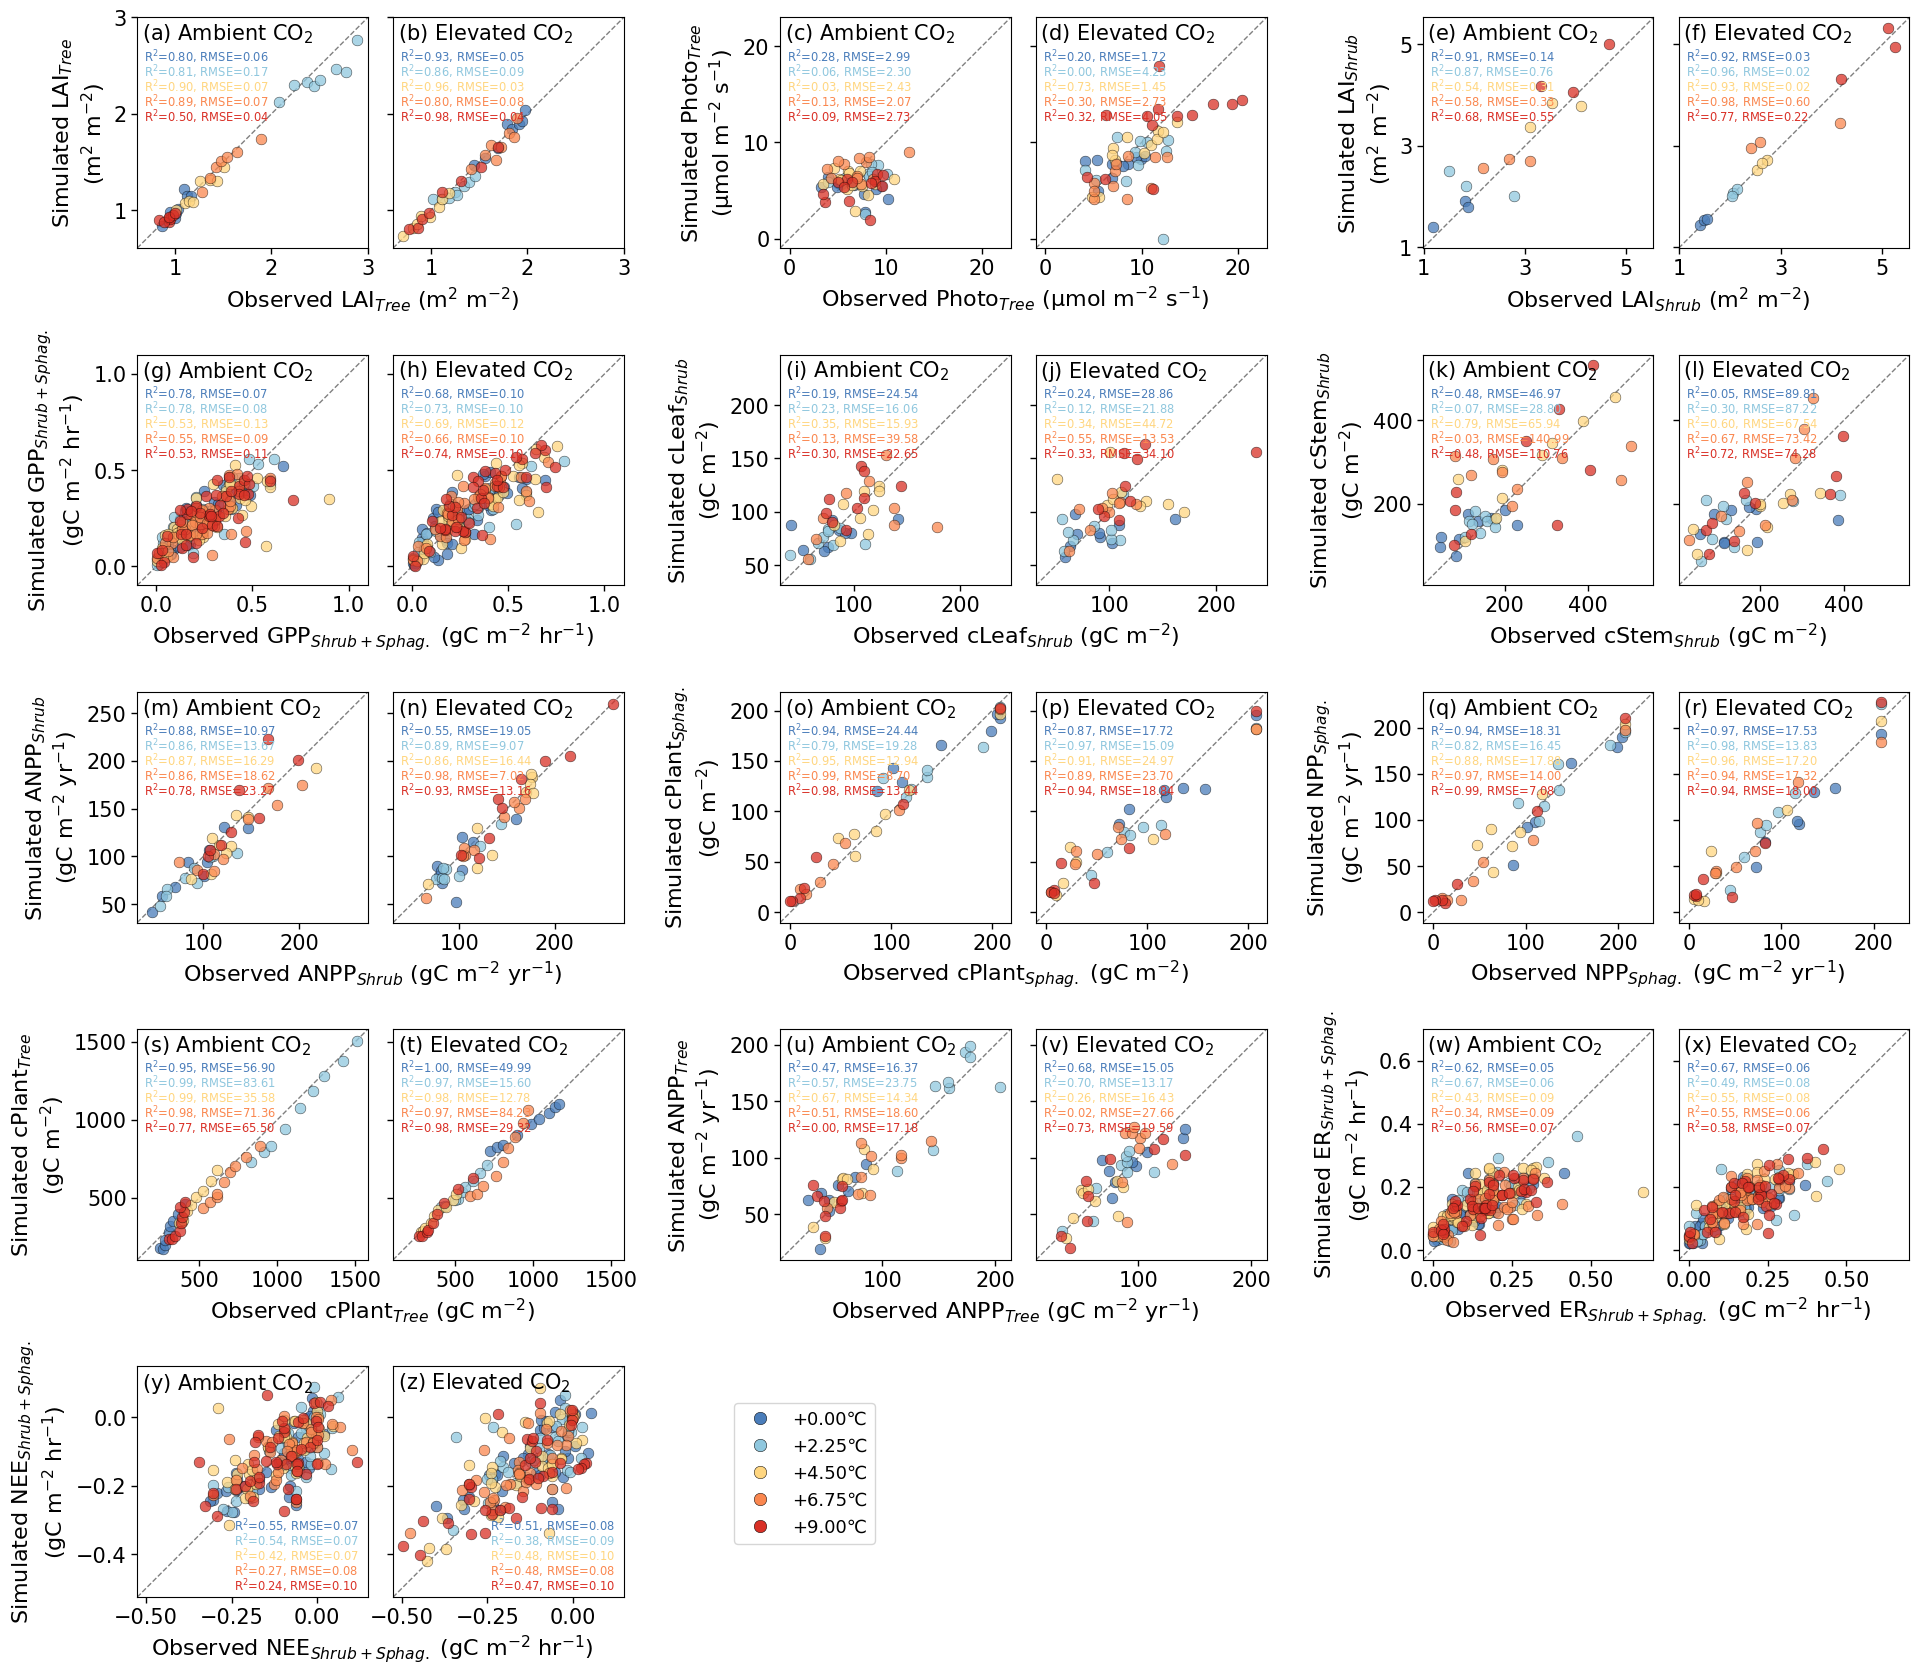

In [1]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from matplotlib.lines import Line2D

# ============================================================
# 1. Variables to plot
# ============================================================
file_names = {
    "laitree": "obsfile_Tree_LAI_h.txt",
    "phototree": "obsfile_Tree_Photo_h.txt",
    "laishrub": "obsfile_Shrub_LAI_h.txt",
    "gpp": "obsfile_gpp_h.txt",

    "cleafshrub": "obsfile_Shrub_cLeaf_y.txt",
    "cstemshrub": "obsfile_Shrub_cStem_y.txt",
    "anppshrub": "obsfile_Shrub_ANPP_y.txt",
    "cplantsphag": "obsfile_Sphag_cPlant_y.txt",
    "nppsphag": "obsfile_Sphag_NPP_y.txt",

    "cplanttree": "obsfile_Tree_PlantC_y.txt",
    "anpptree": "obsfile_Tree_ANPP_y.txt",

    "er": "obsfile_er_h.txt",
    "nee": "obsfile_nee_h.txt",
}

# ============================================================
# 2. Axis labels
# ============================================================
ylabels_map = {
    "cleafshrub": "cLeaf$_{Shrub}$\n(gC m$^{-2}$)",
    "cstemshrub": "cStem$_{Shrub}$\n(gC m$^{-2}$)",
    "anppshrub": "ANPP$_{Shrub}$\n(gC m$^{-2}$ yr$^{-1}$)",
    "laishrub": "LAI$_{Shrub}$\n(m$^{2}$ m$^{-2}$)",
    "cplantsphag": "cPlant$_{Sphag.}$\n(gC m$^{-2}$)",
    "nppsphag": "NPP$_{Sphag.}$\n(gC m$^{-2}$ yr$^{-1}$)",

    "cplanttree": "cPlant$_{Tree}$\n(gC m$^{-2}$)",
    "laitree": "LAI$_{Tree}$\n(m$^{2}$ m$^{-2}$)",
    "phototree": "Photo$_{Tree}$\n(μmol m$^{-2}$ s$^{-1}$)",
    "anpptree": "ANPP$_{Tree}$\n(gC m$^{-2}$ yr$^{-1}$)",

    "gpp": "GPP$_{Shrub+Sphag.}$\n(gC m$^{-2}$ hr$^{-1}$)",
    "er": "ER$_{Shrub+Sphag.}$\n(gC m$^{-2}$ hr$^{-1}$)",
    "nee": "NEE$_{Shrub+Sphag.}$\n(gC m$^{-2}$ hr$^{-1}$)",
}

xlabels_map = {
    key: val.replace("\n", " ")
    for key, val in ylabels_map.items()
}

# ============================================================
# 3. Tick and range presets
# ============================================================
tick_map = {
    "laishrub": [1, 3, 5],
    "laitree": [1, 2, 3],
    "phototree": [0, 10, 20],
    "gpp": [0, 0.5, 1.0],
}

fixed_lim_map = {
    "gpp": (-0.1, 1.1),
    "phototree": (-1, 23),
}

# ============================================================
# 4. Plot settings
# ============================================================
plot_pairs = [
    ("P06", "P19"),
    ("P20", "P11"),
    ("P13", "P04"),
    ("P08", "P16"),
    ("P17", "P10"),
]

warming_labels = ["+0.00℃", "+2.25℃", "+4.50℃", "+6.75℃", "+9.00℃"]
ls_colors = ["#4a7dba", "#8fc7de", "#ffd680", "#fa874f", "#d93026"]

co2_panels = [
    ("Ambient CO$_2$", 0),
    ("Elevated CO$_2$", 1),
]

BASE_DIR = "../../data_results/2_results/2-2_obs_vs_simu"

# ============================================================
# 5. Helper functions
# ============================================================
def get_subplot_label(n):
    alphabet = string.ascii_lowercase
    label = ""

    while True:
        n, r = divmod(n, 26)
        label = alphabet[r] + label
        if n == 0:
            break
        n -= 1

    return f"({label})"


def read_obs_simu(plot_id, var_name):
    file_path = os.path.join(BASE_DIR, f"{plot_id}_{var_name}.xlsx")

    if not os.path.exists(file_path):
        return np.array([]), np.array([])

    df = pd.read_excel(file_path)
    df = df[df["year"] > 2012].copy()

    obs = np.asarray(df["mean"], dtype=float)
    simu = np.asarray(df["simu"], dtype=float)

    mask = np.isfinite(obs) & np.isfinite(simu)

    return obs[mask], simu[mask]


def calc_stats(obs, simu):
    if len(obs) < 2:
        return np.nan, np.nan

    try:
        model = sm.OLS(simu, sm.add_constant(obs)).fit()
        r2 = model.rsquared
    except Exception:
        r2 = np.nan

    try:
        rmse = np.sqrt(mean_squared_error(obs, simu))
    except Exception:
        rmse = np.nan

    return r2, rmse


def get_var_limits(panel_data, var_name):
    if var_name in fixed_lim_map:
        return fixed_lim_map[var_name]

    combined_vals = []

    for pdata in panel_data:
        combined_vals.extend(pdata["all_obs"].tolist())
        combined_vals.extend(pdata["all_simu"].tolist())

    if len(combined_vals) == 0:
        return 0, 1

    combined_vals = np.asarray(combined_vals, dtype=float)

    val_min = np.nanmin(combined_vals)
    val_max = np.nanmax(combined_vals)

    if val_min == val_max:
        pad = 1.0 if val_min == 0 else abs(val_min) * 0.1
    else:
        pad = (val_max - val_min) * 0.05

    return val_min - pad, val_max + pad


def style_panel(ax, var_name, val_min, val_max, show_ylabels=True):
    ax.set_xlim(val_min, val_max)
    ax.set_ylim(val_min, val_max)
    ax.set_aspect("equal", adjustable="box")

    ax.plot(
        [val_min, val_max],
        [val_min, val_max],
        linestyle="--",
        color="grey",
        linewidth=1.0,
        zorder=1
    )

    if var_name in tick_map:
        ticks = tick_map[var_name]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

    ax.tick_params(axis="x", labelsize=15, length=4, width=1)
    ax.tick_params(axis="y", labelsize=15, length=4, width=1)

    if not show_ylabels:
        ax.tick_params(axis="y", labelleft=False)


def plot_obs_simu_panel(ax, pdata, var_name, val_min, val_max, panel_label, show_ylabels=True):
    warming_data = pdata["warming_data"]

    for idx_plot, (obs, simu) in enumerate(warming_data):
        if len(obs) == 0:
            continue

        ax.scatter(
            obs,
            simu,
            s=60,
            color=ls_colors[idx_plot],
            edgecolors="k",
            linewidths=0.35,
            alpha=0.75,
            label=warming_labels[idx_plot],
            zorder=2
        )

    style_panel(ax, var_name, val_min, val_max, show_ylabels=show_ylabels)

    # Panel title
    ax.text(
        0.02, 0.98,
        f"{panel_label} {pdata['co2_title']}",
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=15
    )

    # Statistics
    if var_name == "nee":
        x0 = 0.42
        y0 = 0.35
        dy = 0.065
    else:
        x0 = 0.03
        y0 = 0.87
        dy = 0.065

    for idx_plot, (obs, simu) in enumerate(warming_data):
        r2, rmse = calc_stats(obs, simu)

        if np.isfinite(r2) and np.isfinite(rmse):
            stat_text = f"R$^2$={r2:.2f}, RMSE={rmse:.2f}"
        else:
            stat_text = "R$^2$=NA, RMSE=NA"

        ax.text(
            x0,
            y0 - idx_plot * dy,
            stat_text,
            ha="left",
            va="top",
            transform=ax.transAxes,
            fontsize=8.3,
            color=ls_colors[idx_plot]
        )


def build_panel_data(var_name):
    panel_data = []

    for co2_title, co2_idx in co2_panels:
        warming_data = []
        all_obs = []
        all_simu = []

        for iaco2, ieco2 in plot_pairs:
            plot_id = iaco2 if co2_idx == 0 else ieco2

            obs, simu = read_obs_simu(plot_id, var_name)
            warming_data.append((obs, simu))

            if len(obs) > 0:
                all_obs.extend(obs.tolist())
                all_simu.extend(simu.tolist())

        panel_data.append({
            "co2_title": co2_title,
            "warming_data": warming_data,
            "all_obs": np.asarray(all_obs, dtype=float),
            "all_simu": np.asarray(all_simu, dtype=float),
        })

    return panel_data


# ============================================================
# 6. Figure layout
# ============================================================
var_list = list(file_names.keys())
n_var = len(var_list)
n_var_per_row = 3
nrows = int(np.ceil(n_var / n_var_per_row))

n_axes_per_row = n_var_per_row * 2

fig = plt.figure(figsize=(19, 3.55 * nrows))

left_margin = 0.045
right_margin = 0.015
bottom_margin = 0.075
top_margin = 0.035

within_gap = 0.006
group_gap = 0.075
row_gap = 0.060

total_group_gap = (n_var_per_row - 1) * group_gap
total_within_gap = n_var_per_row * within_gap
usable_width = 1 - left_margin - right_margin - total_group_gap - total_within_gap

ax_w = usable_width / n_axes_per_row
ax_h = (1 - top_margin - bottom_margin - (nrows - 1) * row_gap) / nrows

axes = [[None for _ in range(n_axes_per_row)] for _ in range(nrows)]

for irow in range(nrows):
    y = 1 - top_margin - (irow + 1) * ax_h - irow * row_gap
    x = left_margin

    for ivg in range(n_var_per_row):
        ax_left = fig.add_axes([x, y, ax_w, ax_h])
        axes[irow][ivg * 2] = ax_left

        x_right = x + ax_w + within_gap
        ax_right = fig.add_axes([x_right, y, ax_w, ax_h], sharey=ax_left)
        axes[irow][ivg * 2 + 1] = ax_right

        x = x_right + ax_w + group_gap


# ============================================================
# 7. Main plotting
# ============================================================
idx_abc = 0

for ivar_idx, ivar in enumerate(var_list):
    row = ivar_idx // n_var_per_row
    block = ivar_idx % n_var_per_row

    ax_left = axes[row][block * 2]
    ax_right = axes[row][block * 2 + 1]

    panel_data = build_panel_data(ivar)
    val_min, val_max = get_var_limits(panel_data, ivar)

    for ipanel, ax in enumerate([ax_left, ax_right]):
        panel_label = get_subplot_label(idx_abc)

        plot_obs_simu_panel(
            ax=ax,
            pdata=panel_data[ipanel],
            var_name=ivar,
            val_min=val_min,
            val_max=val_max,
            panel_label=panel_label,
            show_ylabels=(ipanel == 0)
        )

        if ipanel == 0:
            ax.set_ylabel(
                "Simulated " + ylabels_map.get(ivar, ivar),
                fontsize=16
            )

            ax.text(
                1.02,
                -0.22,
                "Observed " + xlabels_map.get(ivar, ivar),
                fontsize=16,
                transform=ax.transAxes,
                ha="center",
                va="center"
            )
        else:
            ax.set_ylabel("")

        idx_abc += 1


# ============================================================
# 8. Hide unused axes
# ============================================================
used_in_last_row = n_var % n_var_per_row

if used_in_last_row != 0:
    last_row = nrows - 1

    for block in range(used_in_last_row, n_var_per_row):
        axes[last_row][block * 2].set_visible(False)
        axes[last_row][block * 2 + 1].set_visible(False)


# ============================================================
# 9. Warming-level legend
# ============================================================
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=ls_colors[i],
        markeredgecolor="k",
        markeredgewidth=0.35,
        markersize=9,
        label=warming_labels[i]
    )
    for i in range(len(warming_labels))
]

fig.legend(
    handles=legend_handles,
    labels=warming_labels,
    loc="lower center",
    ncol=1,
    fontsize=13,
    frameon=True,
    bbox_to_anchor=(0.4, 0.1)
)

plt.show()